In [2]:
import random
from idlelib import testing
from math import floor

import learn
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from prompt_toolkit.widgets import Checkbox

In [3]:
train1 =  pd.read_csv('C:/Users/user/github/EST_15th_NASA/CMaps/train_FD001.txt',sep = " ",header=None)
train2 =  pd.read_csv('C:/Users/user/github/EST_15th_NASA/CMaps/train_FD002.txt',sep = " ",header=None)
train3 =  pd.read_csv('C:/Users/user/github/EST_15th_NASA/CMaps/train_FD003.txt',sep = " ",header=None)
train4 =  pd.read_csv('C:/Users/user/github/EST_15th_NASA/CMaps/train_FD004.txt',sep = " ",header=None)

In [4]:
train1 = train1.iloc[:,:-2]
train2 = train2.iloc[:,:-2]
train3 = train3.iloc[:,:-2]
train4 = train4.iloc[:,:-2]

In [5]:
# Completeness Check
train1.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
dtype: int64

In [6]:
# Variance Threshold = 0
for i in range(0, train1.shape[1]):
    if train1.iloc[:, i].value_counts().shape[0] < 2:
        print(i)

4
5
9
14
20
22
23


Column 4, 5, 9, 14, 20, 22, 23 are constant columns.
Therefore they cannot be predictor variables.

In [7]:
train1 = train1.drop(columns = [4,5,9,14,20,22,23])

In train3 same as train1, but there is variance in column 14.

In [8]:
train3 = train3.drop(columns = [4,5,9,20,22,23])

train 2 and train 4 have no constant columns.

In [9]:
train3.iloc[:,4:].corr()[abs(train3.iloc[:,4:].corr())>0.5]

,6,7,8,10,11,12,13,14,15,16,17,18,19,21,24,25
6,1.000000,0.640503,0.745167,NaN,NaN,0.533915,NaN,NaN,0.762269,NaN,0.532745,NaN,NaN,0.670062,NaN,NaN
7,0.640503,1.000000,0.716890,NaN,NaN,0.637926,0.535074,NaN,0.746093,NaN,0.636513,NaN,NaN,0.677216,NaN,NaN
8,0.745167,0.716890,1.000000,NaN,NaN,0.601272,0.509782,NaN,0.854030,NaN,0.601254,NaN,NaN,0.749907,NaN,NaN
10,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,NaN,1.000000,0.596510,0.579004,0.830550,NaN,0.988725,0.597169,0.601013,-0.826574,NaN,0.802838,0.807138
12,0.533915,0.637926,0.601272,NaN,0.596510,1.000000,0.578587,0.547105,0.660209,0.608298,0.964052,0.519624,NaN,0.662618,NaN,NaN
13,NaN,0.535074,0.509782,NaN,0.579004,0.578587,1.000000,0.560163,0.546839,0.590891,0.578325,0.954354,NaN,0.559109,NaN,NaN
14,NaN,NaN,NaN,NaN,0.830550,0.547105,0.560163,1.000000,NaN,0.836185,0.547460,0.555604,-0.631628,NaN,0.592349,0.600931
15,0.762269,0.746093,0.854030,NaN,NaN,0.660209,0.546839,NaN,1.000000,NaN,0.659375,NaN,NaN,0.783722,NaN,NaN
16,NaN,NaN,NaN,NaN,0.988725,0.608298,0.590891,0.836185,NaN,1.000000,0.608714,0.610383,-0.819711,NaN,0.794781,0.800166


In [10]:
t1 = StandardScaler()
train1.iloc[:,2:] = t1.fit_transform(train1.iloc[:,2:])
train2.iloc[:,2:] = StandardScaler().fit_transform(train2.iloc[:,2:])
train3.iloc[:,2:] = StandardScaler().fit_transform(train3.iloc[:,2:])
train4.iloc[:,2:] = StandardScaler().fit_transform(train4.iloc[:,2:])

C:\Users\user\AppData\Local\Temp\ipykernel_36844\3540112430.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.78170979 -0.78170979 -2.07309423 ...  3.09244354  1.15536688
  1.8010591 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train1.iloc[:,2:] = t1.fit_transform(train1.iloc[:,2:])
C:\Users\user\AppData\Local\Temp\ipykernel_36844\3540112430.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.51557895 -0.65970099 -1.41634166 ... -1.38031116 -1.34428065
 -0.37145692]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train2.iloc[:,2:] = StandardScaler().fit_transform(train2.iloc[:,2:])
C:\Users\user\AppData\Local\Temp\ipykernel_36844\3540112430.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of

In [11]:
def addRUL(train):
    train['RUL'] = (train.groupby(train.columns[0]).transform('size') - train.iloc[:,1])

In [12]:
addRUL(train1)
addRUL(train2)
addRUL(train3)
addRUL(train4)


In [13]:
train1.tail()

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
20626,100,196,-0.178822,-1.031720,1.618000,1.216258,2.188375,0.141683,-2.189329,1.315066,0.012547,1.980044,-2.607969,2.278282,-0.322542,1.425294,2.446751,-1.805173,-2.921113,4
20627,100,197,-0.727453,-1.714186,1.717992,2.279706,2.738351,0.141683,-2.833345,1.878576,-0.006020,1.867718,-2.350355,1.722087,-0.380207,1.913240,1.155367,-2.856395,-1.203764,3
20628,100,198,0.186933,-0.008022,1.478011,1.946971,2.138377,0.141683,-2.742957,2.019453,0.029755,2.054927,-1.902919,2.000184,-0.141684,3.265092,3.092444,-2.081810,-3.292481,2
20629,100,199,-0.498857,1.015677,1.098043,2.403666,1.955051,0.141683,-3.036719,2.160330,0.383884,3.178182,-2.363913,1.861136,-0.233948,2.579834,1.155367,-2.911722,-2.085072,1
20630,100,200,-1.458962,-1.714186,2.337940,1.607712,2.578358,0.141683,-2.912435,2.301208,-0.170405,2.466787,-2.865584,2.278282,-0.336696,1.638604,1.801059,-2.469103,-2.194080,0


In [14]:
def trainerLinear(train, helper = False, opt = False):
    trainsplitidx = int(train.iat[-1,0] * 0.8)
    trainsplit = train[train[0] <= trainsplitidx].copy()
    testsplit = train[train[0] > trainsplitidx].copy()

    X = trainsplit.iloc[:,1:-1]
    y = trainsplit["RUL"]
    model = RidgeCV()
    model.fit(X, y)
    # Test predictions
    y_pred = model.predict(X) # Train fit
    X_test = testsplit.iloc[:,1:-1]
    y_test = testsplit.iloc[:,-1]
    y_test_pred = model.predict(X_test)

    print("On self")
    print(mean_squared_error(y,y_pred))
    print("On test")
    print(mean_squared_error(y_test,y_test_pred))

    if helper:
        ans = model.predict(train.iloc[:,1:-1])
        return ans
    if opt:
        return mean_squared_error(y_test,y_test_pred)

In [15]:
# unaffected by scaling
print("Linear Baseline")
print("dataset 1")
trainerLinear(train1)#.drop([13],inplace=False))
print("dataset 2")
trainerLinear(train2)
print("dataset 3")
trainerLinear(train3)
print("dataset 4")
trainerLinear(train4)

Linear Baseline
dataset 1
On self
1338.5453379521389
On test
2823.6593771406338
dataset 2
On self
1683.529275782564
On test
1650.8065381923823
dataset 3
On self
3533.726905350438
On test
4764.001655036194
dataset 4
On self
3208.769151348456
On test
2747.3685110997662


In [16]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


In [17]:
def trainerNN(train, drop = 0.4,verbose = True):
    trainsplitidx = int(train.iat[-1,0] * 0.8)
    trainsplit = train[train[0] <= trainsplitidx].copy()
    testsplit = train[train[0] > trainsplitidx].copy()

    X = trainsplit.iloc[:,1:-1]
    y = trainsplit["RUL"]


    # from sklearn.preprocessing import StandardScaler

    #standardScaler = StandardScaler()
    #standardScaler.fit_transform(X)
    model = nn.Sequential(
        nn.Linear(X.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.Dropout(drop),
        nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)  # Move model to device immediately after creation

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(params = model.parameters(), lr=0.005, weight_decay=1e-4)

    # Convert pandas DataFrame values to PyTorch tensors and move to device
    X_tensor = torch.FloatTensor(X.values).to(device)
    y_tensor = torch.FloatTensor(y.values).reshape(-1, 1).to(device)  # Move tensors to device

    train_dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tensor, y_tensor),
        batch_size=64,
        shuffle=True
    )

    num_epochs = 20
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for predictors, RUL in train_dataloader:
            predictors, RUL = predictors.to(device), RUL.to(device)
            output = model(predictors)
            loss = criterion(output, RUL)
            epoch_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        epoch_loss /= len(train_dataloader)
        # print(f"Epoch {epoch + 1}, Train Loss: {epoch_loss:.4f}")

    # Test predictions
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        # Predictions on training data
        X_tensor_train = torch.FloatTensor(X.values).to(device)
        y_pred_tensor = model(X_tensor_train)
        y_pred = y_pred_tensor.detach().cpu().numpy().flatten()

        # Predictions on test data
        X_test = testsplit.iloc[:,1:-1]
        #standardScaler.transform(X_test)
        y_test = testsplit.iloc[:,-1]
        X_tensor_test = torch.FloatTensor(X_test.values).to(device)
        y_test_pred_tensor = model(X_tensor_test)
        y_test_pred = y_test_pred_tensor.detach().cpu().numpy().flatten()

    if verbose:
        print("On self")
        print(mean_squared_error(y, y_pred))
        print("On test")
        print(mean_squared_error(y_test, y_test_pred))
    else:
        return mean_squared_error(y_test, y_test_pred)

## NN Baseline (without scaling)
### dataset 1
* On self
1562.8907470703125
* On test
3442.7919921875
### dataset 2
* On self
2379.801513671875
* On test
2386.091552734375
### dataset 3
* On self
6701.88525390625
* On test
7504.6865234375
### dataset 4
* On self
4869.3125
* On test
3603.95166015625

In [18]:
print("NN Baseline")
print("dataset 1")
trainerNN(train1)#.drop([18],inplace=False))  # Dropping column 18 as per previous analysis (marginally better, 13 makes it worse)
print("dataset 2")
trainerNN(train2)
print("dataset 3")
trainerNN(train3,drop = 0.6)
print("dataset 4")
trainerNN(train4,drop = 0.6)

NN Baseline
dataset 1
On self
1086.608642578125
On test
2436.013916015625
dataset 2
On self
1484.0911865234375
On test
1511.7738037109375
dataset 3
On self
2699.229248046875
On test
4532.2802734375
dataset 4
On self
3071.093017578125
On test
2611.330810546875


In [19]:
print("NN Baseline")
print("dataset 1")
trainerNN(train1)#.drop([18],inplace=False))  # Dropping column 18 as per previous analysis (marginally better, 13 makes it worse)
print("dataset 2")
trainerNN(train2)
print("dataset 3")
trainerNN(train3,drop = 0.6)
print("dataset 4")
trainerNN(train4,drop = 0.6)

NN Baseline
dataset 1
On self
1057.3052978515625
On test
2390.995361328125
dataset 2
On self
1499.7220458984375
On test
1534.8389892578125
dataset 3
On self
3045.239990234375
On test
5318.84814453125
dataset 4
On self
3412.784423828125
On test
2832.276611328125


In [20]:
import random

In [21]:
# Dropping makes it worse?
print("NN Baseline")
print("dataset 1")
sum = 0
random.seed(42)  # For reproducibility
for i in range(10):
    sum+=trainerNN(train1)
print(sum/10)
print("dropped")
sum = 0
random.seed(42)  # For reproducibility
for i in range(10):
    sum+=trainerNN(train3.drop([11,17,18],inplace=False))
print(sum/10)

NN Baseline
dataset 1
On self
1125.4630126953125
On test
2697.619873046875


TypeError: unsupported operand type(s) for +=: 'int' and 'NoneType'

In [ ]:
# Dropping makes it worse.
print("NN Baseline")
print("dataset 3")
sum = 0
random.seed(42)  # For reproducibility
for i in range(10):
    sum+=trainerNN(train3,verbose = False)
print(sum/10)
print("dropped")
sum = 0
random.seed(42)  # For reproducibility
for i in range(10):
    sum+=trainerNN(train3.drop([11,17,18],inplace=False),verbose = False)
print(sum/10)

NN Baseline
dataset 3
4382.92470703125
dropped
4647.896215820312


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, data_file):
        processed_data_list = []
        for unit, group in data_file.groupby(0):

            # Extract features and ensure they are numeric
            sequence_features = group.iloc[:,1:-1].values.astype(np.float32)

            # Extract RUL values for each time step in the sequence
            rul_sequence = group["RUL"].values.astype(np.float32)

            processed_data_list.append({
                'unit': unit,
                'sequence': sequence_features, # (time_steps, num_features)
                'RUL': rul_sequence           # (time_steps,)
            })
            self.data = pd.DataFrame(processed_data_list)

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        seq = self.data.at[idx,'sequence']
        label = self.data.at[idx,'RUL']
        return torch.tensor(seq, dtype=torch.float32),torch.tensor(label, dtype=torch.float32)

array([[ 1.0000000e+00, -3.1597969e-01, -1.3729532e+00, ...,
        -7.8170979e-01,  1.3484927e+00,  1.1944270e+00],
       [ 2.0000000e+00,  8.7272191e-01, -1.0317204e+00, ...,
        -7.8170979e-01,  1.0165279e+00,  1.2369219e+00],
       [ 3.0000000e+00, -1.9618742e+00,  1.0156767e+00, ...,
        -2.0730941e+00,  7.3989058e-01,  5.0342280e-01],
       ...,
       [ 1.9000000e+02, -1.2303655e+00,  3.3321103e-01, ...,
         3.0924435e+00, -1.8051730e+00, -2.0527387e+00],
       [ 1.9100000e+02,  4.0553682e-03, -1.3729532e+00, ...,
         5.0967467e-01, -2.0264828e+00, -1.4799811e+00],
       [ 1.9200000e+02,  4.1552901e-01, -8.0218082e-03, ...,
         1.8010591e+00, -1.8605005e+00, -3.0005598e+00]],
      shape=(192, 18), dtype=float32)

In [ ]:
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):

    sequences, ruls = zip(*batch)

    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0.0)
# Consider changing to -inf for transformer
    padded_ruls = pad_sequence(ruls, batch_first=True, padding_value= 0.0)

    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)

    return padded_sequences, padded_ruls, lengths

In [ ]:
train_dataloader = torch.utils.data.DataLoader(
    CustomDataset(train1),
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)
for idx, (predictors, RUL, lengths) in enumerate(train_dataloader):
        print(f"Batch {idx + 1}:")
        print(f"Predictors shape: {predictors.shape}")
        print(f"RUL shape: {RUL.shape}")
        print(f"Lengths: {lengths}")
        break  # Remove this line to iterate through all batches

Batch 1:
Predictors shape: torch.Size([64, 362, 18])
RUL shape: torch.Size([64, 362])
Lengths: tensor([234, 256, 178, 195, 231, 208, 194, 196, 158, 192, 199, 156, 213, 194,
        231, 214, 166, 199, 154, 209, 188, 154, 170, 213, 158, 163, 231, 259,
        180, 214, 165, 240, 185, 195, 135, 213, 150, 137, 179, 283, 283, 222,
        191, 180, 147, 202, 336, 172, 217, 229, 195, 278, 188, 213, 185, 269,
        234, 188, 174, 128, 362, 158, 313, 155])


In [ ]:
class RUL_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout_prob=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size,hidden_size,
                            num_layers= num_layers,
                            batch_first=True,
                            dropout=dropout_prob if num_layers > 1 else 0) # Dropout only between LSTM layers
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.lstm(x)[0]
        x = self.fc(x)

        return x.squeeze(-1) # Squeeze to (batch_size, seq_len)

In [ ]:
def create_loss_mask(batch_size, seq_len, lengths):
    loss_mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)
    for i, length in enumerate(lengths):
        loss_mask[i, :length] = True
    return loss_mask

In [ ]:
def trainerLSTM(train,
                verbose = False,visual = False, stat= True, # verbosity
                color = "blue",label = "LSTM", # aethetics
                num_epochs = 10,batch_size = 64,lr=1e-5, scheduler = lambda x : x,# training hyperparameters
                hidden_dim = 32, num_layers = 2): # model hyperparameters
    trainsplitidx = int(train.iat[-1,0] * 0.8)
    trainsplit = train[train[0] <= trainsplitidx].copy()
    testsplit = train[train[0] > trainsplitidx].copy()

    loss_plot = []

    dataset = CustomDataset(trainsplit)

    train_dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )


    model = RUL_LSTM(train.shape[1]-2,
                     hidden_size=hidden_dim,
                     num_layers=num_layers,
                     dropout_prob= 0.4).to(device)

    criterion = nn.MSELoss() # Mean Squared Error for RUL regression (technically not so good idea because MSE is eval metric as well)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = scheduler(optimizer)

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for predictors, RUL,lengths in train_dataloader:
            predictors, RUL = predictors.to(device), RUL.to(device)
            output = model(predictors)

            # mask = torch.zeros_like(RUL, dtype=torch.bool, device=device)
            # for i, length in enumerate(lengths):
            #     mask[i, :length] = True
            mask= create_loss_mask(predictors.shape[0], predictors.shape[1], lengths)

            masked_output = output[mask]
            masked_RUL = RUL[mask]

            loss = criterion(masked_output, masked_RUL)
            epoch_loss += loss.item()
            optimizer.zero_grad()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping to prevent exploding gradients
            loss.backward()
            optimizer.step()
            if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
                sched.step(loss)  # Step the scheduler with the loss
            else:
                sched.step()


        epoch_loss /= len(train_dataloader)
        if verbose:
            print(f"Epoch {epoch + 1}, Train Loss: {epoch_loss:.4f}")
        if visual:
            loss_plot.append(epoch_loss)

    # Test predictions
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        # Predictions on training data
        train_dataset = CustomDataset(trainsplit)
        train_dataloader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
        )

        train_preds, train_targets = [], []
        for predictors, RUL, lengths in train_dataloader:
            predictors, RUL = predictors.to(device), RUL.to(device)
            output = model(predictors)

            # Extract valid predictions using mask
            mask = torch.zeros_like(RUL, dtype=torch.bool, device=device)
            for i, length in enumerate(lengths):
                mask[i, :length] = True

            train_preds.extend(output[mask].cpu().numpy())
            train_targets.extend(RUL[mask].cpu().numpy())

        # Predictions on test data
        test_dataset = CustomDataset(testsplit)
        test_dataloader = torch.utils.data.DataLoader(
            test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
        )

        test_preds, test_targets = [], []
        for predictors, RUL, lengths in test_dataloader:
            predictors, RUL = predictors.to(device), RUL.to(device)
            output = model(predictors)

            # Extract valid predictions using mask
            mask = torch.zeros_like(RUL, dtype=torch.bool, device=device)
            for i, length in enumerate(lengths):
                mask[i, :length] = True

            test_preds.extend(output[mask].cpu().numpy())
            test_targets.extend(RUL[mask].cpu().numpy())

        # Convert to numpy arrays for MSE calculation
        y_pred = np.array(train_preds)
        y = np.array(train_targets)
        y_test_pred = np.array(test_preds)
        y_test = np.array(test_targets)

    if stat:
        print("On self")
        print(mean_squared_error(y, y_pred))
        print("On test")
        print(mean_squared_error(y_test, y_test_pred))

    if visual:
        sns.lineplot(pd.Series(loss_plot), color = color,label = label)
    #return mean_squared_error(y_test, y_test_pred)

In [ ]:
def paddingMask(batch_size,seq_len, lengths):
    padding_mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)
    for i, length in enumerate(lengths):
        if length < seq_len:
            padding_mask[i, length:] = True  # True = ignore these positions
    return padding_mask

LSTM training is extremely unstable and it doesn't seem to learn anything. Despite a lot of debugging, it still doesn't work.
Scaling, learning rate,number of layer, hidden size, have no effect and data shape has been checked too

In [ ]:
trainerLSTM(train1)
trainerLSTM(train2)
trainerLSTM(train3)
trainerLSTM(train4)

On self
15267.7392578125
On test
20282.951171875
On self
16534.0703125
On test
16338.654296875
On self
28547.869140625
On test
29970.68359375
On self
26220.890625
On test
24100.740234375


In [ ]:
class RUL_Decoder(nn.Module):
    def __init__(self, input_s,d_model=16, nhead=4, dim_feedforward = 64, dropout=0.3,batch_first=True,num_layers=4):
        super().__init__()
        self.embedding = nn.Linear(input_s, d_model)  # Input layer to project input features to d_model dimensions
        # (mainly because different datasets have different number of features, and d_model needs to be divisible by nhead)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward = dim_feedforward, dropout=dropout,batch_first=batch_first)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)  # Output layer to predict RUL (from d_model to 1)

    def forward(self, x,mask,src_key_padding_mask,is_causal):
        # PyTorch applies linear layers to last dimension
        x = self.embedding(x)
        # Transformer expects input shape (batch_size, seq_len, d_model)
        x = self.encoder(x,mask=mask,src_key_padding_mask = src_key_padding_mask,is_causal=is_causal)
        #Transformer should give output shape (batch_size, seq_len, d_model)
        x = self.fc(x)
        return x.squeeze(-1) # Squeeze to (batch_size, seq_len)

In [ ]:
def causalMask(seqlen):
    mask = torch.ones((seqlen, seqlen), dtype = torch.bool, device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask

<Axes: xlabel='1', ylabel='6'>

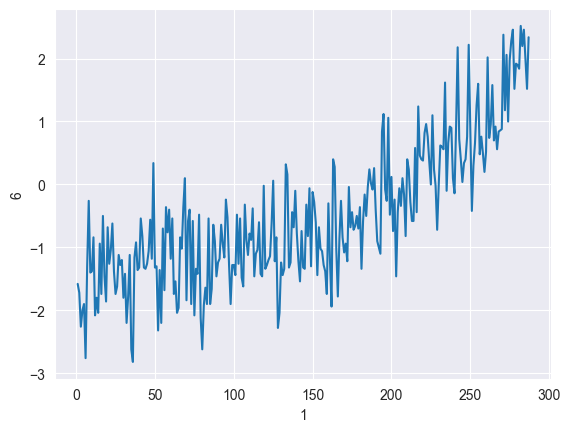

In [ ]:
train11 = train1[train1[0] == 2].copy()
sns.lineplot(train11,x=train11.iloc[:,1],y=train11.iloc[:,4])

In [ ]:
def predictDecoder(predictors, RUL, lengths, model):
    predictors, RUL = predictors.to(device), RUL.to(device)
    batch_size,seq_len,_ = predictors.shape
    # Create causal mask (same for all sequences)
    cmask = causalMask(seq_len)
    # Create padding mask (different for each sequence based on length)
    pmask = paddingMask(batch_size, seq_len, lengths)

    output = model(predictors,
                   mask=cmask,
                   src_key_padding_mask=pmask,
                   is_causal=True)

    loss_mask= create_loss_mask(batch_size, seq_len, lengths)
    masked_output = output[loss_mask]
    masked_RUL = RUL[loss_mask]
    return masked_output, masked_RUL

In [ ]:
def trainerNaiveDecoder(train,
                verbose = False,visual = False, stat= True, # verbosity
                color = "blue",label = "Decoder", # aethetics
                num_epochs = 10,batch_size = 64,lr=1e-5, dropout = 0.5, # training hyperparameters
                patience = 30, max_val = None, min_del = 5,valPlot = False,
                hidden_dim = 32, num_layers = 2,# model hyperparameters
                testing = False, opt = False):
    trainsplitidx = int(train.iat[-1,0] * 0.8)
    trainsplit = train[train[0] <= trainsplitidx].copy()
    testsplit = train[train[0] > trainsplitidx].copy()

    loss_plot = []
    val_loss_plot = []
    best_loss_plot = []
    pTracker = 0
    best_loss = float("inf")

    def val_loss():
        # Predictions on test data
        test_dataset = CustomDataset(testsplit)
        test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

        i = 0
        test_preds, test_targets = [], []
        for predictors, RUL, lengths in test_dataloader:
            masked_output, masked_RUL = predictDecoder(predictors, RUL, lengths, model)
            test_preds.extend(masked_output.cpu().detach().numpy())
            test_targets.extend(masked_RUL.cpu().detach().numpy())
            if max_val and i >= max_val: break

        y_test_pred = np.array(test_preds)
        y_test = np.array(test_targets)
        return mean_squared_error(y_test, y_test_pred)

    dataset = CustomDataset(trainsplit)

    train_dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    model = RUL_Decoder(train.shape[1]-2,dropout = dropout,
                        dim_feedforward = hidden_dim, num_layers= num_layers ).to(device)

    criterion = nn.MSELoss() # Mean Squared Error for RUL regression (technically not so good idea because MSE is eval metric as well)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0


        for predictors, RUL,lengths in train_dataloader:
            masked_output, masked_RUL = predictDecoder(predictors, RUL, lengths, model)
            loss = criterion(masked_output, masked_RUL)

            epoch_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping to prevent exploding gradients
            optimizer.step()

        curr_loss = val_loss()
        val_loss_plot.append(curr_loss)
        best_loss_plot.append(best_loss)
        if curr_loss >= best_loss - min_del:
            pTracker += 1
        if pTracker > patience: break
        else:
            best_loss = curr_loss
            pTracker = 0

        epoch_loss /= len(train_dataloader)
        if verbose:
            print(f"* Epoch {epoch + 1}, Train Loss: {epoch_loss:.4f}")
        if visual:
            loss_plot.append(epoch_loss)

    # Test predictions
    model.train()  # eval mode uses flash attention which doesn't work for mps
    with torch.no_grad():
        # Predictions on training data
        train_dataset = CustomDataset(trainsplit)
        train_dataloader = torch.utils.data.DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
        )

        train_preds, train_targets = [], []
        for predictors, RUL, lengths in train_dataloader:
            masked_output, masked_RUL = predictDecoder(predictors, RUL, lengths, model)
            train_preds.extend(masked_output.cpu().numpy())
            train_targets.extend(masked_RUL.cpu().numpy())


        # Convert to numpy arrays for MSE calculation
        y_pred = np.array(train_preds)
        y = np.array(train_targets)


    if stat:
        print("## On self")
        print(mean_squared_error(y, y_pred))
        print("## On test")
        val = val_loss()
        print(val)

    if visual:
        sns.lineplot(pd.Series(loss_plot), color = color,label = label)
        if valPlot:
            sns.lineplot(pd.Series(val_loss_plot), color = "orange",label = "val loss")
            sns.lineplot(pd.Series(best_loss_plot), color = "green",label = "best loss")
    if testing:
        return model
    if opt:
        return val

    #return mean_squared_error(y_test, y_test_pred)

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"]="1"

In [ ]:
trainerNaiveDecoder(train1)

Epoch 1, Train Loss: 14633.3247
Epoch 2, Train Loss: 15137.2036
Epoch 3, Train Loss: 15077.0039
Epoch 4, Train Loss: 16172.9033
Epoch 5, Train Loss: 14645.8799
Epoch 6, Train Loss: 14415.6221
Epoch 7, Train Loss: 14987.8364
Epoch 8, Train Loss: 15002.9761
Epoch 9, Train Loss: 15052.6162
Epoch 10, Train Loss: 16291.4399
On self
15251.2177734375
On test
20259.12109375


## 4 layers:

* Epoch 1, Train Loss: 15865.4092
* Epoch 2, Train Loss: 15451.1392
* Epoch 3, Train Loss: 14298.1616
* Epoch 4, Train Loss: 14750.9336
* Epoch 5, Train Loss: 14079.5186
* Epoch 6, Train Loss: 15915.4844
* Epoch 7, Train Loss: 15375.0342
* Epoch 8, Train Loss: 15470.4624
* Epoch 9, Train Loss: 15564.7544
* Epoch 10, Train Loss: 15096.6631
### On self

15380.025390625
### On test

20406.599609375

## 16 layers

* Epoch 1, Train Loss: 15447.8301
* Epoch 2, Train Loss: 14261.5044
* Epoch 3, Train Loss: 14652.2764
* Epoch 4, Train Loss: 15210.0869
* Epoch 5, Train Loss: 15015.2681
* Epoch 6, Train Loss: 15037.3140
* Epoch 7, Train Loss: 14827.7607
* Epoch 8, Train Loss: 15174.0742
* Epoch 9, Train Loss: 14653.0566
* Epoch 10, Train Loss: 14491.8696
## On self
15357.3564453125
## On test
20379.16796875

## Dropout = 0.5 , 4 layers

* Epoch 1, Train Loss: 14257.1992
* Epoch 2, Train Loss: 15227.1665
* Epoch 3, Train Loss: 16267.6821
* Epoch 4, Train Loss: 15849.3657
* Epoch 5, Train Loss: 14757.3320
* Epoch 6, Train Loss: 13975.0264
* Epoch 7, Train Loss: 16490.7085
* Epoch 8, Train Loss: 15674.5239
* Epoch 9, Train Loss: 14763.8062
* Epoch 10, Train Loss: 16160.4375
## On self
15306.5751953125
## On test
20323.255859375

In [ ]:
trainerNaiveDecoder(train1)

* Epoch 1, Train Loss: 14257.1992
* Epoch 2, Train Loss: 15227.1665
* Epoch 3, Train Loss: 16267.6821
* Epoch 4, Train Loss: 15849.3657
* Epoch 5, Train Loss: 14757.3320
* Epoch 6, Train Loss: 13975.0264
* Epoch 7, Train Loss: 16490.7085
* Epoch 8, Train Loss: 15674.5239
* Epoch 9, Train Loss: 14763.8062
* Epoch 10, Train Loss: 16160.4375
## On self
15306.5751953125
## On test
20323.255859375


In [ ]:
train4["RUL"].max()

np.int64(542)

<Axes: xlabel='1', ylabel='val'>

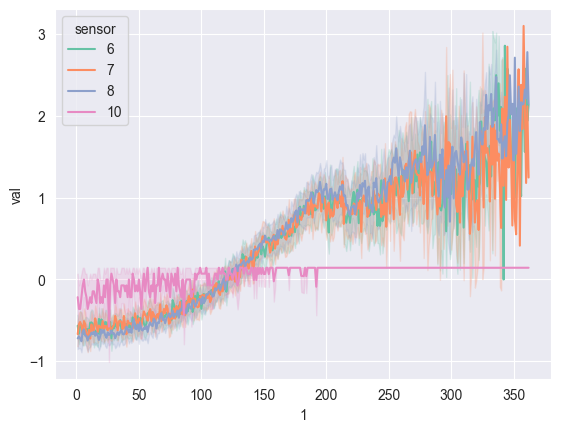

In [ ]:
df_long = pd.melt(train1.iloc[:,:-1],
                  id_vars=[0,1],
                  value_vars=[6,7,8,10],
                  var_name='sensor',
                  value_name='val')
sns.lineplot(df_long,x=1,y='val',hue='sensor',palette='Set2')

Optimise hyperparameters (maybe genetic algorithms)

Try to bring it closer to test set

Do parameter on predictor variable optimisation

In [ ]:
# Filter the data, and plot both the original and filtered signals.
data = train11.iloc[:,5]
y = butter_lowpass_filter(data, 15, 2)

NameError: name 'train11' is not defined

In [ ]:
import numpy as np
from scipy.signal import butter,filtfilt
import plotly.graph_objects as go
# Filter requirements.
t_duration = 5.0         # Sample Period
fs = 30.0       # sample rate, Hz
cutoff = 2      # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
  # Nyquist Frequency
order = 2       # sin wave can be approx represented as quadratic
n = int(t_duration* fs) # total number of samples

In [ ]:
# --- FIX: Generate a time vector ---
# Create a time vector from 0 to t_duration with n samples
t = np.linspace(0, t_duration, n, endpoint=False)

# --- FIX: Generate a signal over the time vector ---
# sin wave using the time vector 't'
sig = np.sin(1.2 * 2 * np.pi * t)
# Add some noise using the time vector 't'
noise = 1.5 * np.cos(9 * 2 * np.pi * t) + 0.5 * np.sin(12.0 * 2 * np.pi * t)
data = sig + noise

In [ ]:
def butter_lowpass_filter(data, cutoff, order):
    """
    Butterworth lowpass filter.

    I use a default sampling frequency of 200 Hz, so that cutoff can be a number from 0 to 100.

    :param data: series data
    :param cutoff: Cutoff frequency of the filter, Hz
    :param order: smoothness of the filter, higher order means more tolerance of higher frequencies
    :return: smoothened series data
    """

    normal_cutoff = cutoff / 100 # normalising frequency to nyquist frequency
    # Get the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    y = data,
    line =  dict(shape =  'spline' ),
    name = 'signal with noise'
))
fig.add_trace(go.Scatter(
    y = y,
    line =  dict(shape =  'spline' ),
    name = 'filtered signal'
))
fig.show()

NameError: name 'data' is not defined

In [ ]:
def smooth(X,smoothing_param):
    data = X.apply(lambda x: butter_lowpass_filter(x,smoothing_param, 2), axis=0)
    data["RUL"]= X["RUL"]
    data.iloc[:,0:2]= X.iloc[:,0:2]
    return data

In [ ]:
train1low5 = train1.apply(lambda x: butter_lowpass_filter(x,5, 2), axis=0)

currently looks like 5>10 kinda, lr 0.05,

In [ ]:
trainerLSTM(train1low5,visual=False,stat=True,label = "lstm1",color = "red",num_epochs=20,lr = 5e-2,num_layers=1)

On self
2010.5439453125
On test
3348.398193359375


In [ ]:
trainerLinear(train1low5)

On self
1253.9925083616229
On test
2622.292967261894


## On self
1031.726318359375
## On test
2157.06201171875
## On self
1054.4417724609375
## On test
2343.455078125
## On self
1067.961181640625
## On test
2338.33544921875
## On self
1074.184814453125
## On test
2379.1728515625


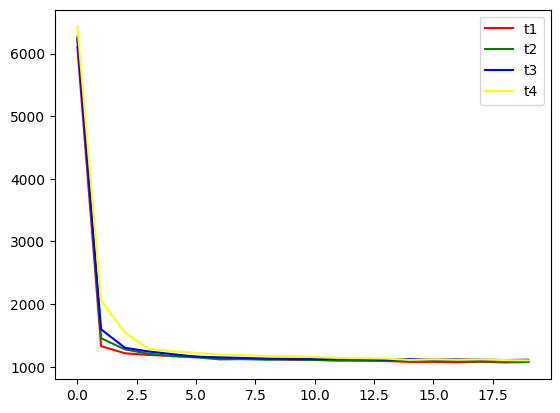

In [ ]:
# 20 epochs are necessary no flatline, loss with hidden dimension doesn't scale at all beyond noise
# test num_layers, t1 - t64 are nearly same, but do cause time difference ☹️
import matplotlib.pyplot as plt
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "red",label = "t1", lr = 1e-2,hidden_dim=4, num_layers=1)
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "green",label = "t2", lr = 1e-2, hidden_dim=4, num_layers=2)
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "blue",label = "t3", lr = 1e-2, hidden_dim=4, num_layers=3)
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "yellow",label = "t4", lr = 1e-2, hidden_dim=4, num_layers=4)


## On self
1083.67626953125
## On test
2414.94091796875
## On self
1067.49267578125
## On test
2334.0009765625
## On self
1099.5867919921875
## On test
2499.66552734375
## On self
2758.80712890625
## On test
4167.1669921875


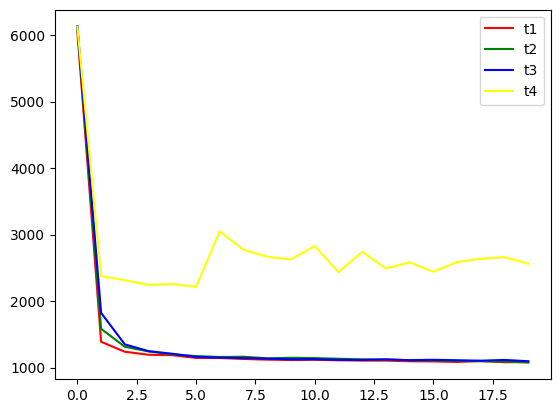

In [ ]:
# Sanity Check with hidden dimension 32
import matplotlib.pyplot as plt
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "red",label = "t1", lr = 1e-2, num_layers=1)
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "green",label = "t2", lr = 1e-2,  num_layers=2)
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "blue",label = "t3", lr = 1e-2,  num_layers=3)
trainerNaiveDecoder(train1low52,visual = True, stat=True,num_epochs=20,color = "yellow",label = "t4", lr = 1e-2, num_layers=4)

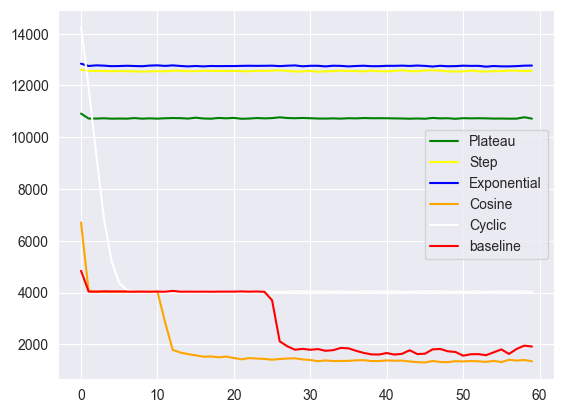

In [ ]:
# only some parameters are exposed, if time, try others too
# lr > 1e-3

trainerLSTM(train1low10,visual=True,stat=False,num_epochs=60,color = "green",label = "Plateau", lr = 5e-2, scheduler= lambda optimizer: torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=7))
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=60,color = "yellow",label = "Step", lr = 5e-2, scheduler = lambda optimizer: torch.optim.lr_scheduler.StepLR(optimizer, step_size=10))
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=60,color = "blue",label = "Exponential", lr = 5e-2, scheduler= lambda optimizer: torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9))
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=60,color = "orange",label = "Cosine", lr = 5e-2, scheduler= lambda optimizer: torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10))
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=60,color = "white",label = "Cyclic", lr = 5e-2, scheduler= lambda optimizer: torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-4, max_lr=1e-2))
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=60,color = "red",label = "baseline", lr = 5e-2)
#Overtraining to see loss landscape



# Addendum
## Testing Different Low Pass Filters

In [ ]:
train1low = train1.apply(lambda x: butter_lowpass_filter(x,20, 2), axis=0)
train1low15 = train1.apply(lambda x: butter_lowpass_filter(x,15, 2), axis=0)
train1low25 = train1.apply(lambda x: butter_lowpass_filter(x,25, 2), axis=0)
train1low10 = train1.apply(lambda x: butter_lowpass_filter(x,10, 2), axis=0)
train1low30 = train1.apply(lambda x: butter_lowpass_filter(x,30, 2), axis=0)

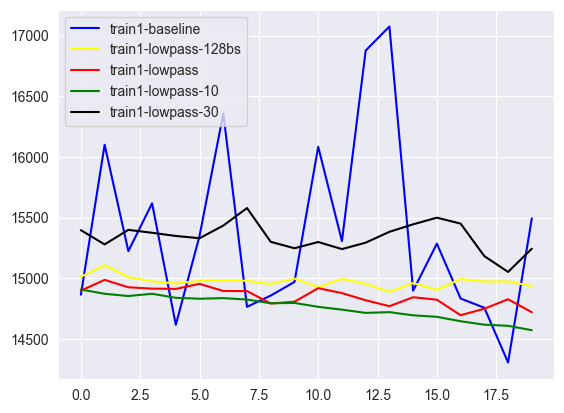

In [ ]:
trainerLSTM(train1,visual=True,stat=False,num_epochs=20, label = "train1-baseline")
trainerLSTM(train1low,visual=True,stat=False,num_epochs=20,color = "yellow",label = "train1-lowpass-128bs",batch_size=128)
trainerLSTM(train1low,visual=True,stat=False,num_epochs=20,color = "red",label = "train1-lowpass")
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "green",label = "train1-lowpass-10")
trainerLSTM(train1low30,visual=True,stat=False,num_epochs=20,color = "black",label = "train1-lowpass-30")
plt.legend() # Display the legend with the labels
plt.show()

In [ ]:
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "green",label = "train1-lowpass-10")
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "yellow",label = "train1-lowpass-5")
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "black",label = "train1-lowpass-10-lr4",lr = 1e-4)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "orange",label = "train1-lowpass-5-lr4", lr = 1e-4)
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "black",label = "train1-lowpass-10-lr3",lr = 1e-3)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "orange",label = "train1-lowpass-5-lr3", lr = 1e-3)

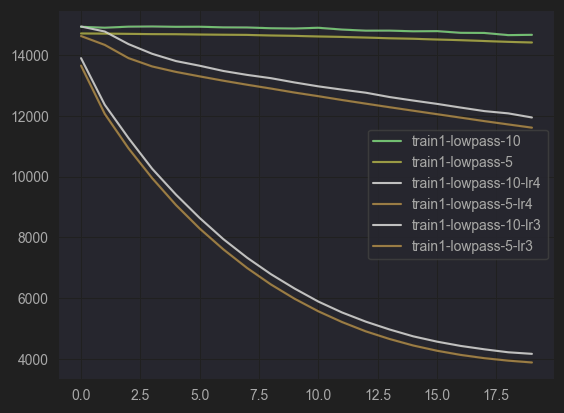

Similar for encoder but almost no difference between different datasets

In [ ]:
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "black",label = "train1-lowpass-5-lr3",lr = 1e-3)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "orange",label = "train1-lowpass-5-lr2", lr = 1e-2)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "green",label = "train1-lowpass-5-lr1",lr = 1e-1)
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "red",label = "train1-lowpass-10-lr2", lr = 1e-2)
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "yellow",label = "train1-lowpass-10-lr1", lr = 1e-1)

KeyboardInterrupt: 

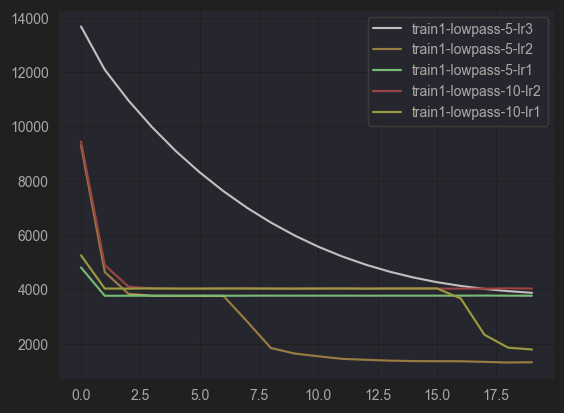

## Encoder

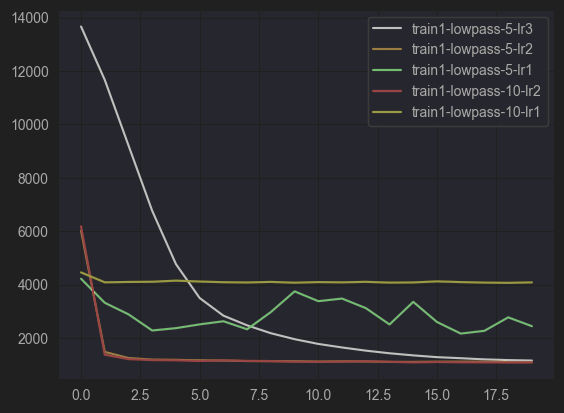

In [ ]:
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "black",label = "train1-lowpass-5-lr53",lr = 5e-3)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "red",label = "train1-lowpass-5-lr52",lr = 5e-2)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "orange",label = "train1-lowpass-5-lr2", lr = 1e-2)
trainerLSTM(train1low10,visual=True,stat=False,num_epochs=20,color = "yellow",label = "train1-lowpass-10-lr52", lr = 5e-2)

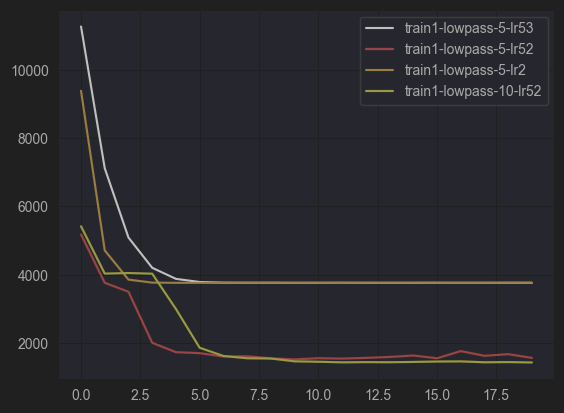

Encoder

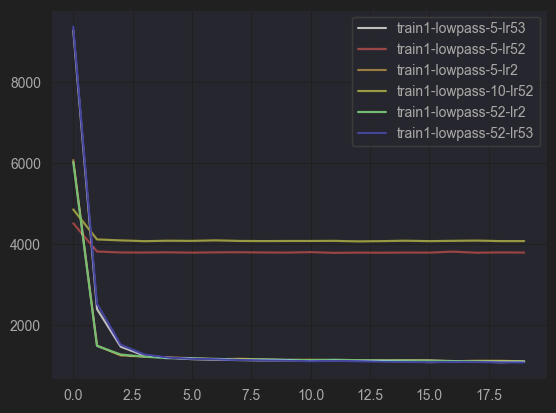

In [ ]:
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "red",label = "train1-baseline-8",lr = 5e-2,hidden_dim=8)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "blue",label = "train1-baseline-16",lr = 5e-2,hidden_dim=16)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "green",label = "train1-baseline",lr = 5e-2)
trainerLSTM(train1low5,visual=True,stat=False,num_epochs=20,color = "orange",label = "train1-baseline-64",lr = 5e-2,hidden_dim=64)

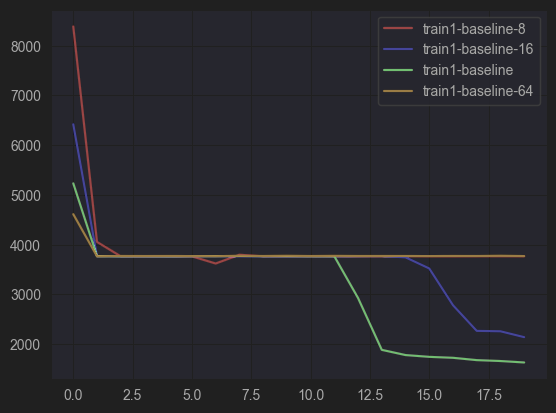



In [ ]:
trainerLSTM(train1low5,visual=True,stat=False,label = "lstm1",color = "red",num_epochs=20,lr = 5e-2,num_layers=1)
trainerLSTM(train1low5,visual=True,stat=False,label = "lstm2",color = "yellow",num_epochs=20,lr = 5e-2,num_layers=2)
trainerLSTM(train1low5,visual=True,stat=False,label = "lstm3",color = "orange",num_epochs=20,lr = 5e-2,num_layers=3)
trainerLSTM(train1low5,visual=True,stat=False,label = "lstm4",color = "green",num_epochs=20,lr = 5e-2,num_layers=4)

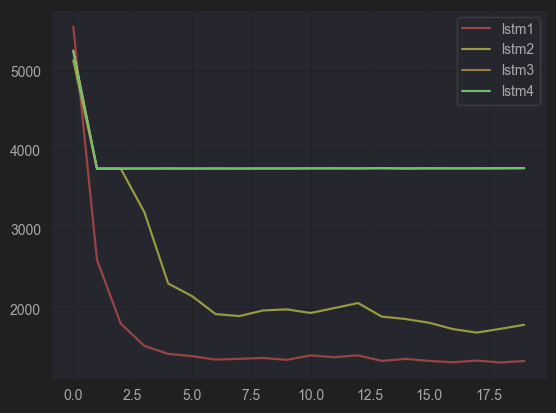

<Axes: xlabel='1', ylabel='13'>

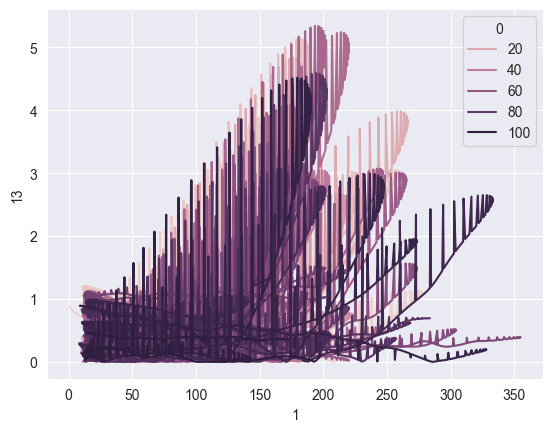

In [ ]:
sns.lineplot(train1low5,x=train1low5.iloc[:,1],y=train1low5.iloc[:,10]),hue = train1.iloc[:,0])

## On self
1145.9339599609375
## On test
2203.524658203125
## On self
1050.8321533203125
## On test
2165.06884765625
## On self
1049.8226318359375
## On test
2148.7353515625
## On self
1070.793212890625
## On test
2310.13134765625
## On self
1046.01318359375
## On test
2317.79296875

In [ ]:
train1low52 = train1low5.copy()
train1low52.iloc[:,10] = abs(train1low52.iloc[:,10])

In [ ]:
# absolute value of 10th column
trainerNN(train1low52)
trainerNN(train1low5)

On self
1108.4448740232765
On test
2262.977178643089
On self
1087.2976062553828
On test
2527.950904924443


Worsens linear but helps nn for some reason

In [ ]:
trainerLSTM(train1low52,visual=False,stat=True,label = "lstm1",color = "red",num_epochs=20,lr = 5e-2,num_layers=1)

On self
1317.5350341796875
On test
2597.961669921875


In [ ]:
trainerNaiveDecoder(train1low52,visual=False,stat=True,label = "lstm1",color = "red",num_epochs=20,lr = 1e-2,num_layers=1,hidden_dim=4)

## On self
1049.9073486328125
## On test
2373.325439453125


In [ ]:
train1low53 = train1low52.copy()
linearPred = trainerLinear(train1low5, helper = True)
train1low53.insert(17, "linearPred", linearPred)

On self
1260.1225092868942
On test
2610.2758783991203


In [ ]:
trainerNN(train1low53)

On self
1086.0829662365757
On test
2573.049256963621


In [ ]:
trainerLSTM(train1low53,visual=False,stat=True,label = "lstm",color = "red",num_epochs=20,lr = 5e-2,num_layers=1)

On self
1299.48876953125
On test
2666.56396484375


Rises on self for encoder sadly, but test is better, so it is probably underfitting

In [ ]:
trainerNaiveDecoder(train1low53,visual=False,stat=True,label = "decoder",color = "red",num_epochs=20,lr = 1e-2,num_layers=1,hidden_dim=4)

## On self
1115.5577392578125
## On test
2204.71435546875


In [ ]:
trainerNaiveDecoder(train1low53,visual=False,stat=True,label = "decoder",color = "red",num_epochs=20,lr = 1e-2,num_layers=2,hidden_dim=4)
trainerNaiveDecoder(train1low53,visual=False,stat=True,label = "decoder",color = "red",num_epochs=20,lr = 1e-2,num_layers=3,hidden_dim=4)
trainerNaiveDecoder(train1low53,visual=False,stat=True,label = "decoder",color = "red",num_epochs=20,lr = 1e-2,num_layers=4,hidden_dim=4)
trainerNaiveDecoder(train1low53,visual=False,stat=True,label = "decoder",color = "red",num_epochs=20,lr = 1e-2,num_layers=4,hidden_dim=16)

## On self
1045.3509521484375
## On test
2172.99609375
## On self
1060.822265625
## On test
2206.8681640625
## On self
1118.364990234375
## On test
2350.4189453125
## On self
1213.8701171875
## On test
2495.049072265625


In [ ]:
# Dropout...
trainerNaiveDecoder(train1low53,visual=False,stat=True,label = "decoder",color = "red",num_epochs=20,lr = 1e-2,num_layers=2,hidden_dim=4,dropout = 0.3)

# 0.5 offers better train loss somehow

## On self
1050.570068359375
## On test
2097.67919921875
## On self
1087.669677734375
## On test
2203.510009765625
## On self
1036.869140625
## On test
2183.703125
## On self
1058.3272705078125
## On test
2343.9267578125
## On self
1053.677734375
## On test
2177.240234375


In [ ]:
train1low5 = train1.apply(lambda x: butter_lowpass_filter(x,45, 2), axis=0)
train1low5["RUL"]= train1["RUL"]
train1low5[0:2]= train1[0:2]

In [ ]:
train1low5

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,1.0,1.000000,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,191
1,1.0,2.000000,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,190
2,1.0,2.996713,-0.559262,-0.574484,-1.164551,-0.458360,-0.829359,0.141683,1.023902,-0.549477,-0.733497,-0.744034,0.875297,-0.835087,-0.452752,-0.804352,-0.921703,0.998806,0.974297,189
3,1.0,4.004241,-0.640053,-0.281368,-0.960697,-0.588809,-0.824706,0.141683,0.993506,-0.593769,-0.687473,-0.926155,1.028675,-0.775671,-0.520201,-0.889171,-0.953830,0.897522,0.894511,188
4,1.0,5.007411,-0.687972,-0.063233,-0.831362,-0.663401,-0.854849,0.141683,0.960969,-0.661497,-0.660903,-1.058535,1.088094,-0.752383,-0.572491,-0.949926,-0.960320,0.859047,0.847572,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.008376,-0.368930,-0.332700,1.600601,1.709731,2.276109,0.141683,-2.320634,1.886967,0.069037,2.255233,-2.297738,2.005038,-0.203027,2.241734,1.691197,-2.504577,-2.002451,4
20627,100.0,197.028967,-0.539885,-0.609179,1.706822,1.726193,2.349936,0.141683,-2.470379,1.951401,0.035669,2.288101,-2.395629,2.047996,-0.236213,2.192168,1.714729,-2.529240,-2.068258,3
20628,100.0,198.059728,-0.783961,-0.922414,1.866065,1.718116,2.421878,0.141683,-2.623166,2.048628,-0.015499,2.341025,-2.521645,2.105652,-0.269017,2.077993,1.744644,-2.529574,-2.126732,2
20629,100.0,199.100402,-1.101501,-1.296609,2.081453,1.675493,2.501593,0.141683,-2.768728,2.170405,-0.085618,2.406180,-2.681871,2.182463,-0.302937,1.894392,1.768811,-2.514037,-2.167770,1


In [ ]:
train1low52 = train1low5.copy()
train1low52.iloc[:,10] = abs(train1low52.iloc[:,10])

In [ ]:
train1low53 = train1low52.copy()
linearPred = trainerLinear(train1low5, helper = True)
train1low53.insert(17, "linearPred", linearPred)

On self
1366.2606444877956
On test
2698.529554266791


In [ ]:
trainerLinear(train1)

On self
1338.545337952141
On test
2823.6593761218337


In [ ]:
trainerLinear(train1low5)

On self
1628.4756039742497
On test
3053.246243999533


In [ ]:
trainerNN(train1)

On self
1046.599853515625
On test
2372.09765625


In [ ]:
trainerNN(train1low5)

# trainerNN(train1low52)
#
# trainerNN(train1low53)

On self
1081.25927734375
On test
2351.811767578125


In [ ]:
device = "mps"

In [ ]:
def makeLin(trains):
    train_92 = smooth(trains,92)
    X = train_92.iloc[:,1:-1]
    y = train_92["RUL"]
    linModel = RidgeCV()
    linModel.fit(X, y)
    return linModel

In [ ]:
def addLin(X,smoothing_param,linModel):
    data = smooth(X,smoothing_param)
    data.iloc[:, 10] = abs(data.iloc[:, 10])
    #linearPred = linModel.predict(data.iloc[:,1:-1])
    #data.insert(17, "linearPred", linearPred)
    return data

## On self
431.4890441894531
## On test
1554.985107421875


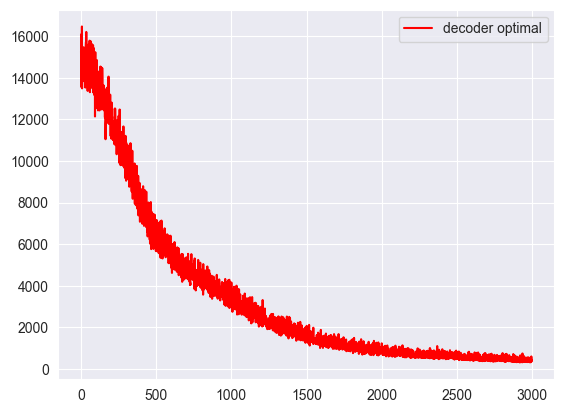

In [ ]:
NNModel = trainerNaiveDecoder(addLin(train1,5,makeLin(train1)),visual=True,stat=True,label = "decoder optimal",color = "red",num_epochs=3000,lr = 0.001,num_layers=1,hidden_dim=128,dropout = 0.027708272959952207,testing = True, patience=15)
# import matplotlib.pyplot as plt
# plt.ylim(0,1000)

In [ ]:
trainerNaiveDecoder(addLin(train1,5,makeLin(train1)),visual=True,stat=True,label = "decoder optimal",color = "red",num_epochs=3000,lr = 0.001,num_layers=1,hidden_dim=128,dropout = 0.027708272959952207,valPlot = True)

## On self
336.4280700683594
## On test
1589.5830078125


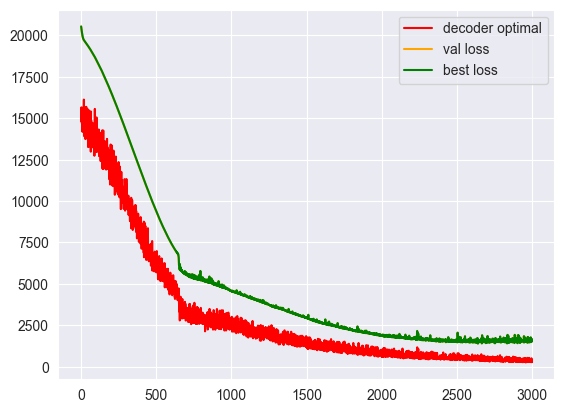

In [ ]:
trainerNaiveDecoder(addLin(train1,5,makeLin(train1)),visual=True,stat=True,label = "decoder optimal",color = "red",num_epochs=3000,lr = 0.001,num_layers=1,hidden_dim=128,dropout = 0.027708272959952207,valPlot = True, patience=15)

## On self
560.8235473632812
## On test
1862.3385009765625


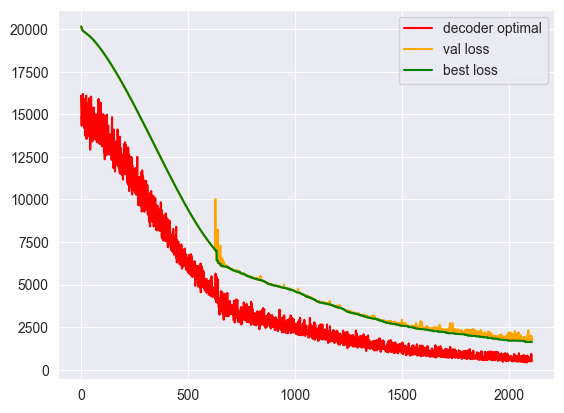

In [ ]:
trainerNaiveDecoder(addLin(train1,5,makeLin(train1)),visual=True,stat=True,label = "decoder optimal",color = "red",num_epochs=100000,lr = 0.001,num_layers=2,hidden_dim=128,dropout = 0.027708272959952207,valPlot = True)

## On self
910.6258544921875
## On test
2429.190185546875


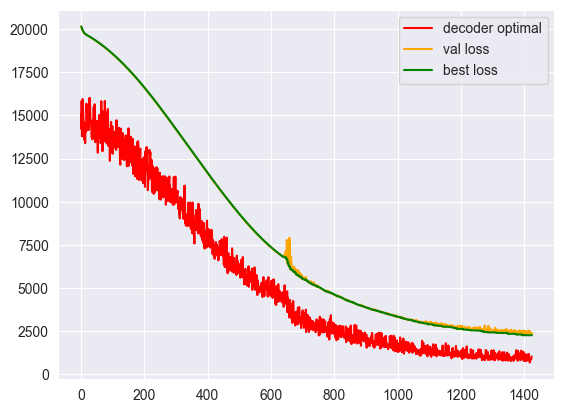

In [ ]:
trainerNaiveDecoder(addLin(train1,5,makeLin(train1)),visual=True,stat=True,label = "decoder optimal",color = "red",num_epochs=100000,lr = 0.001,num_layers=2,hidden_dim=64,dropout = 0.027708272959952207,valPlot = True)

old test to fix smooth

## On self
709.9034423828125
## On test
2081.61181640625


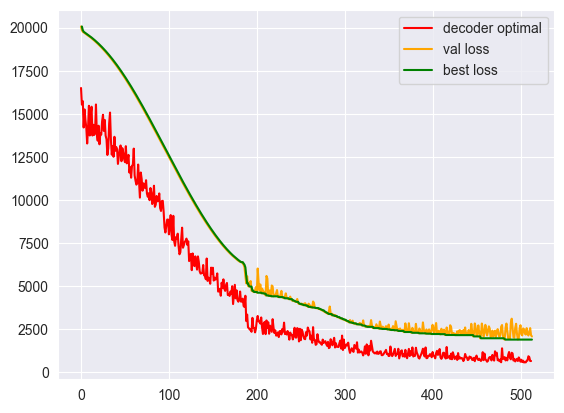

In [ ]:
trainerNaiveDecoder(addLin(train1,15,makeLin(train1)),visual=True,stat=True,label = "decoder optimal",color = "red",num_epochs=1000,lr = 0.0036702249418152175,num_layers=3,hidden_dim=128,dropout = 0.0,valPlot = True)

In [ ]:
type(NNModel)

__main__.RUL_Decoder

In [ ]:
def testModel(testsplit,model):
    test_dataset = CustomDataset(testsplit)
    test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn
    )
    test_preds, test_targets = [], []
    for predictors, RUL, lengths in test_dataloader:
        masked_output, masked_RUL = predictDecoder(predictors, RUL, lengths, model)
        test_preds.extend(masked_output.cpu().detach().numpy())
        test_targets.extend(masked_RUL.cpu().detach().numpy())
    y_test_pred = np.array(test_preds)
    y_test = np.array(test_targets)
    print(y_test)
    print(y_test_pred)
    print("On test dataset:")
    print(mean_squared_error(y_test, y_test_pred))

In [ ]:
test1 = pd.read_csv('./CMaps/train_FD001.txt',sep = " ",header=None)

In [ ]:
test1 = test1.iloc[:,:-2]

In [ ]:
test1 = test1.drop(columns = [4,5,9,14,20,22,23])

KeyError: '[4, 5, 9, 14, 20, 22, 23] not found in axis'

In [ ]:
test1

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,1,1,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,191
1,1,2,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,190
2,1,3,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423,189
3,1,4,0.324090,-0.008022,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792,188
4,1,5,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.178822,-1.031720,1.618000,1.216258,2.188375,0.141683,-2.189329,1.315066,0.012547,1.980044,-2.607969,2.278282,-0.322542,1.425294,2.446751,-1.805173,-2.921113,4
20627,100,197,-0.727453,-1.714186,1.717992,2.279706,2.738351,0.141683,-2.833345,1.878576,-0.006020,1.867718,-2.350355,1.722087,-0.380207,1.913240,1.155367,-2.856395,-1.203764,3
20628,100,198,0.186933,-0.008022,1.478011,1.946971,2.138377,0.141683,-2.742957,2.019453,0.029755,2.054927,-1.902919,2.000184,-0.141684,3.265092,3.092444,-2.081810,-3.292481,2
20629,100,199,-0.498857,1.015677,1.098043,2.403666,1.955051,0.141683,-3.036719,2.160330,0.383884,3.178182,-2.363913,1.861136,-0.233948,2.579834,1.155367,-2.911722,-2.085072,1


In [ ]:
train1

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,1,1,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,191
1,1,2,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,190
2,1,3,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423,189
3,1,4,0.324090,-0.008022,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792,188
4,1,5,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.178822,-1.031720,1.618000,1.216258,2.188375,0.141683,-2.189329,1.315066,0.012547,1.980044,-2.607969,2.278282,-0.322542,1.425294,2.446751,-1.805173,-2.921113,4
20627,100,197,-0.727453,-1.714186,1.717992,2.279706,2.738351,0.141683,-2.833345,1.878576,-0.006020,1.867718,-2.350355,1.722087,-0.380207,1.913240,1.155367,-2.856395,-1.203764,3
20628,100,198,0.186933,-0.008022,1.478011,1.946971,2.138377,0.141683,-2.742957,2.019453,0.029755,2.054927,-1.902919,2.000184,-0.141684,3.265092,3.092444,-2.081810,-3.292481,2
20629,100,199,-0.498857,1.015677,1.098043,2.403666,1.955051,0.141683,-3.036719,2.160330,0.383884,3.178182,-2.363913,1.861136,-0.233948,2.579834,1.155367,-2.911722,-2.085072,1


In [ ]:
test1.iloc[:,2:] = t1.transform(test1.iloc[:,2:])

/var/folders/zq/bls12nhj5lz6sld5f___pk640000gn/T/ipykernel_7639/4244088841.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.78170979 -0.78170979 -2.07309423 ...  3.09244354  1.15536688
  1.8010591 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test1.iloc[:,2:] = t1.transform(test1.iloc[:,2:])


In [ ]:
test1low5 = smooth(test1,15)
test1low52 = test1low5.copy()
test1low52.iloc[:, 10] = abs(test1low52.iloc[:, 10])
test1low53 = test1low52.copy()

# train1_92 = smooth(train1,92)
# X = train1_92.iloc[:,1:-1]
# y = train1_92["RUL"]
# linModel = RidgeCV()
# linModel.fit(X, y)

#linearPred = linModel.predict(test1low52.iloc[:,1:-1])
#test1low53.insert(17, "linearPred", linearPred)

In [ ]:
ans = pd.read_csv('./CMaps/RUL_FD001.txt', header=None)

In [ ]:
addRUL(test1)

In [ ]:
test1low53.tail()

,0,1,2,3,6,7,8,10,11,12,...,15,16,17,18,19,21,linearPred,24,25,RUL
20626,100.0,196.008376,-0.368930,-0.332700,1.600601,1.709731,2.276109,0.141683,-2.320634,1.886967,...,2.255233,-2.297738,2.005038,-0.203027,2.241734,1.691197,-2.006233,-2.504577,-2.002451,4
20627,100.0,197.028967,-0.539885,-0.609179,1.706822,1.726193,2.349936,0.141683,-2.470379,1.951401,...,2.288101,-2.395629,2.047996,-0.236213,2.192168,1.714729,-4.507190,-2.529240,-2.068258,3
20628,100.0,198.059728,-0.783961,-0.922414,1.866065,1.718116,2.421878,0.141683,-2.623166,2.048628,...,2.341025,-2.521645,2.105652,-0.269017,2.077993,1.744644,-7.263624,-2.529574,-2.126732,2
20629,100.0,199.100402,-1.101501,-1.296609,2.081453,1.675493,2.501593,0.141683,-2.768728,2.170405,...,2.406180,-2.681871,2.182463,-0.302937,1.894392,1.768811,-10.480725,-2.514037,-2.167770,1
20630,100.0,200.147303,-1.467323,-1.723990,2.335523,1.608267,2.590650,0.141683,-2.907154,2.304892,...,2.473776,-2.866259,2.273108,-0.338323,1.662821,1.788929,-13.810122,-2.489407,-2.194970,0


In [ ]:
test1

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,1,1,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,191
1,1,2,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,190
2,1,3,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423,189
3,1,4,0.324090,-0.008022,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792,188
4,1,5,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.178822,-1.031720,1.618000,1.216258,2.188375,0.141683,-2.189329,1.315066,0.012547,1.980044,-2.607969,2.278282,-0.322542,1.425294,2.446751,-1.805173,-2.921113,4
20627,100,197,-0.727453,-1.714186,1.717992,2.279706,2.738351,0.141683,-2.833345,1.878576,-0.006020,1.867718,-2.350355,1.722087,-0.380207,1.913240,1.155367,-2.856395,-1.203764,3
20628,100,198,0.186933,-0.008022,1.478011,1.946971,2.138377,0.141683,-2.742957,2.019453,0.029755,2.054927,-1.902919,2.000184,-0.141684,3.265092,3.092444,-2.081810,-3.292481,2
20629,100,199,-0.498857,1.015677,1.098043,2.403666,1.955051,0.141683,-3.036719,2.160330,0.383884,3.178182,-2.363913,1.861136,-0.233948,2.579834,1.155367,-2.911722,-2.085072,1


In [ ]:
test1low53.groupby(test1low53.columns[0]).head()

,0,1,2,3,6,7,8,10,11,12,...,15,16,17,18,19,21,linearPred,24,25,RUL
0,1.0,0.746744,-0.168055,-1.381460,-1.594895,-0.233270,-0.921650,0.141683,1.170129,-0.469799,...,-0.202057,0.315339,-1.092132,-0.245241,-0.636096,-0.839793,158.554348,1.370857,1.121432,0.253256
1,1.0,1.661108,-0.210901,-1.207982,-1.517190,-0.266022,-0.924740,0.141683,1.121380,-0.479381,...,-0.315954,0.365052,-1.050312,-0.287022,-0.656703,-0.830228,162.130161,1.317422,1.104567,-0.661108
2,1.0,2.600044,-0.247699,-1.038648,-1.436386,-0.299999,-0.928339,0.141683,1.075162,-0.487725,...,-0.424749,0.413564,-1.009896,-0.327465,-0.677990,-0.822355,165.382270,1.265435,1.085573,-1.600044
3,1.0,3.560011,-0.277911,-0.876255,-1.354549,-0.333830,-0.932661,0.141683,1.031730,-0.494714,...,-0.526914,0.459273,-0.971454,-0.365990,-0.699057,-0.815615,168.295699,1.215845,1.065362,-2.560011
4,1.0,4.537708,-0.301165,-0.722966,-1.273365,-0.366269,-0.937740,0.141683,0.991233,-0.500117,...,-0.621210,0.501174,-0.935303,-0.402155,-0.719122,-0.809698,170.860861,1.169276,1.044690,-3.537708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,195.744254,-0.688843,-0.768745,1.953319,1.577526,2.210997,0.141683,-2.509389,2.050618,...,2.241710,-2.413971,2.115766,-0.241050,1.743161,1.778466,-10.202906,-2.253885,-1.982032,-194.744254
20627,100.0,196.454191,-0.783902,-0.878767,2.007995,1.587740,2.262673,0.141683,-2.569561,2.087689,...,2.278165,-2.479681,2.145229,-0.253020,1.732894,1.791552,-13.201229,-2.286872,-2.016240,-195.454191
20628,100.0,197.107086,-0.878286,-0.989451,2.062397,1.595670,2.310962,0.141683,-2.627414,2.123748,...,2.311831,-2.542526,2.173167,-0.264794,1.718574,1.803416,-16.099854,-2.315721,-2.047796,-196.107086
20629,100.0,197.698361,-0.969956,-1.098251,2.115524,1.601381,2.355390,0.141683,-2.681941,2.158145,...,2.342393,-2.601697,2.199370,-0.276134,1.700954,1.813992,-18.850143,-2.340466,-2.076315,-196.698361


In [ ]:
test1low53.iloc[:,0] = test1.iloc[:,0] - 1


In [ ]:
test1low53["RUL"] = test1low53["RUL"] + test1low53[0].map(ans[0])

In [ ]:
test1low53[test1low53["RUL"].isna()]

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL


In [ ]:
test1low53

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,0.00000,0.96210,-0.35490,-1.36812,-1.74993,-0.10824,-0.92631,0.14168,1.10553,-0.52666,0.86003,-0.28370,0.33748,-1.05015,-0.27535,-0.59511,-0.76805,1.34177,1.20994,303
1,0.00000,1.98312,-0.46008,-0.94622,-1.43639,-0.29079,-0.86747,0.14168,1.06057,-0.53089,0.79341,-0.52325,0.63336,-0.93085,-0.36954,-0.70271,-0.85657,1.15477,1.08337,302
2,0.00000,2.99671,-0.55926,-0.57448,-1.16455,-0.45836,-0.82936,0.14168,1.02390,-0.54948,0.73350,-0.74403,0.87530,-0.83509,-0.45275,-0.80435,-0.92170,0.99881,0.97430,301
3,0.00000,4.00424,-0.64005,-0.28137,-0.96070,-0.58881,-0.82471,0.14168,0.99351,-0.59377,0.68747,-0.92615,1.02867,-0.77567,-0.52020,-0.88917,-0.95383,0.89752,0.89451,300
4,0.00000,5.00741,-0.68797,-0.06323,-0.83136,-0.66340,-0.85485,0.14168,0.96097,-0.66150,0.66090,-1.05853,1.08809,-0.75238,-0.57249,-0.94993,-0.96032,0.85905,0.84757,299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,99.00000,196.00838,-0.36893,-0.33270,1.60060,1.70973,2.27611,0.14168,-2.32063,1.88697,0.06904,2.25523,-2.29774,2.00504,-0.20303,2.24173,1.69120,-2.50458,-2.00245,24
20627,99.00000,197.02897,-0.53989,-0.60918,1.70682,1.72619,2.34994,0.14168,-2.47038,1.95140,0.03567,2.28810,-2.39563,2.04800,-0.23621,2.19217,1.71473,-2.52924,-2.06826,23
20628,99.00000,198.05973,-0.78396,-0.92241,1.86606,1.71812,2.42188,0.14168,-2.62317,2.04863,0.01550,2.34102,-2.52164,2.10565,-0.26902,2.07799,1.74464,-2.52957,-2.12673,22
20629,99.00000,199.10040,-1.10150,-1.29661,2.08145,1.67549,2.50159,0.14168,-2.76873,2.17040,0.08562,2.40618,-2.68187,2.18246,-0.30294,1.89439,1.76881,-2.51404,-2.16777,21


In [ ]:
test1low53

,0,1,2,3,6,7,8,10,11,12,...,15,16,17,18,19,21,linearPred,24,25,RUL
0,0.0,0.962095,-0.354896,-1.368117,-1.749929,-0.108243,-0.926306,0.141683,1.105535,-0.526656,...,-0.283702,0.337479,-1.050150,-0.275355,-0.595114,-0.768050,174.391945,1.341766,1.209939,303
1,0.0,1.983121,-0.460083,-0.946219,-1.436392,-0.290792,-0.867468,0.141683,1.060571,-0.530893,...,-0.523248,0.633360,-0.930855,-0.369535,-0.702712,-0.856574,176.299555,1.154774,1.083374,302
2,0.0,2.996713,-0.559262,-0.574484,-1.164551,-0.458360,-0.829359,0.141683,1.023902,-0.549477,...,-0.744034,0.875297,-0.835087,-0.452752,-0.804352,-0.921703,178.077072,0.998806,0.974297,301
3,0.0,4.004241,-0.640053,-0.281368,-0.960697,-0.588809,-0.824706,0.141683,0.993506,-0.593769,...,-0.926155,1.028675,-0.775671,-0.520201,-0.889171,-0.953830,179.527787,0.897522,0.894511,300
4,0.0,5.007411,-0.687972,-0.063233,-0.831362,-0.663401,-0.854849,0.141683,0.960969,-0.661497,...,-1.058535,1.088094,-0.752383,-0.572491,-0.949926,-0.960320,180.507799,0.859047,0.847572,299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,99.0,196.008376,-0.368930,-0.332700,1.600601,1.709731,2.276109,0.141683,-2.320634,1.886967,...,2.255233,-2.297738,2.005038,-0.203027,2.241734,1.691197,-2.006233,-2.504577,-2.002451,24
20627,99.0,197.028967,-0.539885,-0.609179,1.706822,1.726193,2.349936,0.141683,-2.470379,1.951401,...,2.288101,-2.395629,2.047996,-0.236213,2.192168,1.714729,-4.507190,-2.529240,-2.068258,23
20628,99.0,198.059728,-0.783961,-0.922414,1.866065,1.718116,2.421878,0.141683,-2.623166,2.048628,...,2.341025,-2.521645,2.105652,-0.269017,2.077993,1.744644,-7.263624,-2.529574,-2.126732,22
20629,99.0,199.100402,-1.101501,-1.296609,2.081453,1.675493,2.501593,0.141683,-2.768728,2.170405,...,2.406180,-2.681871,2.182463,-0.302937,1.894392,1.768811,-10.480725,-2.514037,-2.167770,21


In [ ]:
test1["RUL"].max()

np.int64(361)

In [ ]:
testModel(test1low53,NNModel)

[303. 302. 301. ...  22.  21.  20.]
[191.18364  190.45631  190.92084  ...  16.954166  19.428398  15.259069]
On test dataset:
9062.79296875


In [ ]:
from skopt.space import Real, Integer

search_spaces = {
    'smoothing_param' : Integer(5,95),
    #'num_epochs': Integer(100, 1000),  # Example range
    'lr': Real(1e-3, 1e-1, prior='log-uniform'), # Example range
    'num_layers': Integer(1, 5),     # Example range
    'hidden_dim': Integer(2, 128),   # Example range
    'dropout': Real(0.0, 0.8)        # Example range
}

In [ ]:
from sklearn.base import BaseEstimator

class BlackBoxOptimizer(BaseEstimator):
    def __init__(self, trains = None,smoothing_param=0.5, lr=0.01, num_layers=2, hidden_dim=4, dropout=0.3,patience = 30):
        # Store all hyperparameters that BayesSearchCV will tune.
        # These correspond to the arguments trainerNaiveDecoder expects.
        self.smoothing_param = smoothing_param
       # self.num_epochs = num_epochs
        self.lr = lr
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        self.trains = trains
        self.linModel = makeLin(trains)
        self.patience = patience
        # This will store the loss returned by trainerNaiveDecoder
        self.val_loss_ = None

    def fit(self, X, y=None):
        """
        The 'fit' method is called by BayesSearchCV.
        """
        data = addLin(X,self.smoothing_param,self.linModel)
        self.val_loss_ = trainerNaiveDecoder(
            data,
            stat=True,
            num_epochs=10000, # safety net, should be much lower due to early stopping
            lr=self.lr,
            num_layers=self.num_layers,
            hidden_dim=self.hidden_dim,
            dropout=self.dropout,
            opt = True,
            patience = self.patience
        )
        return self

    def score(self, X, y=None):
        """
        The 'score' method is called by BayesSearchCV to get the performance metric.
        BayesSearchCV *maximizes* scores. Since we want to *minimize* loss,
        we return the negative of the validation loss.
        """
        # Ensure that fit has been called and val_loss_ is set
        if self.val_loss_ is None:
            raise ValueError("Fit method must be called before score.")
        return -self.val_loss_

In [ ]:
train1low = smooth(train1,20)
train1low15 = smooth(train1,15)
train1low25 = smooth(train1,25)
train1low10 = smooth(train1,10)
train1low30 = smooth(train1,30)


Tune batch size manually

Remember to use pretrained linear model for linearPred, not retrained

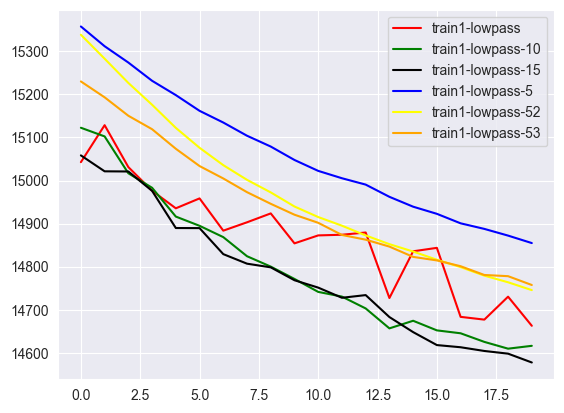

In [ ]:
trainerNaiveDecoder(train1low, visual=True, stat=False, num_epochs=20, color="red", label="train1-lowpass")
trainerNaiveDecoder(train1low10, visual=True, stat=False, num_epochs=20, color="green", label="train1-lowpass-10")
trainerNaiveDecoder(train1low15, visual=True, stat=False, num_epochs=20, color="black", label="train1-lowpass-15")
trainerNaiveDecoder(train1low5, visual=True, stat=False, num_epochs=20, color="blue", label="train1-lowpass-5")
trainerNaiveDecoder(train1low52, visual=True, stat=False, num_epochs=20, color="yellow", label="train1-lowpass-52")
trainerNaiveDecoder(train1low53, visual=True, stat=False, num_epochs=20, color="orange", label="train1-lowpass-53")
plt.legend()  # Display the legend with the labels
plt.show()

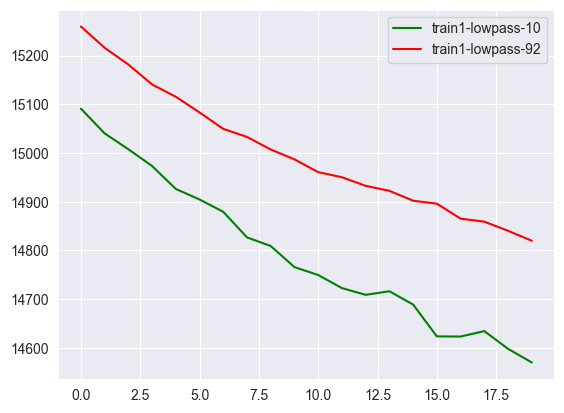

In [ ]:
trainerNaiveDecoder(train1low10, visual=True, stat=False, num_epochs=20, color="green", label="train1-lowpass-10")
trainerNaiveDecoder(smooth(train1,92), visual=True, stat=False, num_epochs=20, color="red", label="train1-lowpass-92")

In [ ]:
train1low5 = smooth(train1,5)
train1low52 = train1low5.copy()
train1low52.iloc[:, 10] = abs(train1low52.iloc[:, 10])
train1low53 = train1low52.copy()
linearPred = trainerLinear(train1low5, helper=True)
train1low53.insert(17, "linearPred", linearPred)

On self
1628.4494721502383
On test
3053.458380896841


In [ ]:
train1low5 = smooth(train1,10)
train1low52 = train1low5.copy()
train1low52.iloc[:, 10] = abs(train1low52.iloc[:, 10])
train1low53 = train1low52.copy()
linearPred = trainerLinear(smooth(train1,47), helper=True)
train1low53.insert(17, "linearPred", linearPred)

On self
1330.4741037197432
On test
2807.3042826257138


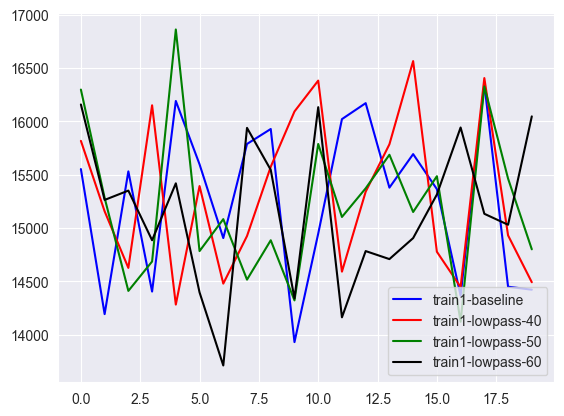

In [ ]:
temp = train1.iloc[:,:6]
addRUL(temp)
trainerLSTM(temp,visual=True,stat=False,num_epochs=20, label = "train1-baseline")
trainerLSTM(smooth(train1,10),visual=True,stat=False,num_epochs=20,color = "red",label = "train1-lowpass-40")
trainerLSTM(smooth(train1,50),visual=True,stat=False,num_epochs=20,color = "green",label = "train1-lowpass-50")
trainerLSTM(smooth(train1,60),visual=True,stat=False,num_epochs=20,color = "black",label = "train1-lowpass-60")
plt.legend() # Display the legend with the labels
plt.show()

In [ ]:
train1low10

,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,1.0,1.0,-0.356462,-1.372520,-1.771094,-0.113023,-0.926831,0.141683,1.107502,-0.528912,-0.860871,-0.297137,0.328197,-1.055268,-0.273092,-0.589966,-0.760469,1.345306,1.226504,191
1,1.0,2.0,-0.430093,-1.057995,-1.573406,-0.225143,-0.913958,0.141683,1.058113,-0.554500,-0.818752,-0.480322,0.487860,-0.982898,-0.345270,-0.665993,-0.796252,1.239022,1.152298,190
2,1.0,3.0,-0.491253,-0.762323,-1.384732,-0.335321,-0.906051,0.141683,1.013477,-0.579149,-0.780075,-0.651191,0.628564,-0.918975,-0.412048,-0.739364,-0.827887,1.144087,1.081204,189
3,1.0,4.0,-0.535666,-0.498480,-1.217184,-0.434607,-0.906431,0.141683,0.972833,-0.603821,-0.747516,-0.802039,0.737023,-0.867573,-0.470862,-0.804715,-0.850831,1.068171,1.018865,188
4,1.0,5.0,-0.559330,-0.271695,-1.077145,-0.515803,-0.915608,0.141683,0.934320,-0.626719,-0.723011,-0.927675,0.807699,-0.829565,-0.520547,-0.857980,-0.864585,1.014712,0.968386,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,-0.569895,-0.491451,1.771838,1.667642,2.277703,0.141683,-2.424456,1.979586,0.012634,2.301047,-2.393885,2.066025,-0.213870,2.007402,1.766859,-2.395024,-2.028664,4
20627,100.0,197.0,-0.763141,-0.763303,1.881730,1.672672,2.359658,0.141683,-2.540275,2.047862,-0.022670,2.344280,-2.502139,2.110441,-0.242495,1.964654,1.775752,-2.436770,-2.079300,3
20628,100.0,198.0,-0.983117,-1.059673,2.015223,1.667529,2.439664,0.141683,-2.664166,2.127808,-0.065795,2.390818,-2.620980,2.162109,-0.272544,1.889784,1.788389,-2.464683,-2.127719,2
20629,100.0,199.0,-1.224926,-1.377202,2.168903,1.651580,2.518665,0.141683,-2.791302,2.215954,-0.115658,2.438971,-2.749427,2.220709,-0.303473,1.785749,1.802648,-2.481168,-2.171739,1


<Axes: xlabel='1', ylabel='3'>

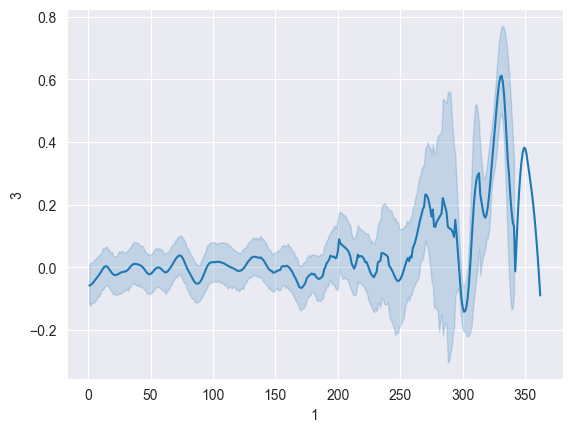

In [ ]:
sns.lineplot(train1low10,x=1,y=3)
#sns.lineplot(train1,x=1,y=4, color = "red")

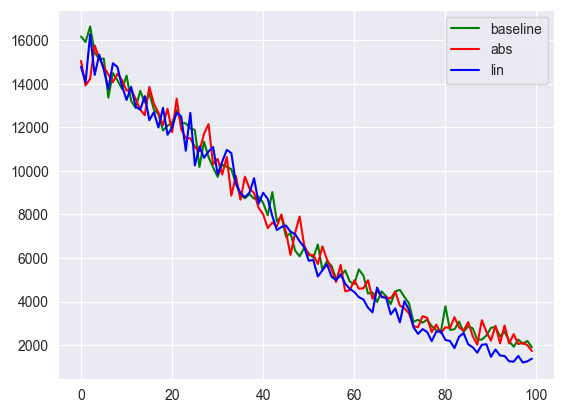

In [ ]:
trainerNaiveDecoder(train1low5, visual=True, stat=False, num_epochs=100, color="green", label="baseline", lr = 1e-2)
trainerNaiveDecoder(train1low52, visual=True, stat=False, num_epochs=100, color="red", label="abs",lr = 1e-2)
trainerNaiveDecoder(train1low53, visual=True, stat=False, num_epochs=100, color="blue", label="lin", lr = 1e-2)

In [ ]:
trainerLinear(train1low)
trainerLinear(train1low5)
trainerLinear(train1)
trainerLinear(train1low10)
trainerLinear(train1low25)

On self
1399.491123643882
On test
2787.424027621585
On self
1349.6500903590322
On test
2865.1237250007266
On self
1338.545337952141
On test
2823.6593761218337
On self
1473.1374309019657
On test
2881.7582104183325
On self
1391.9930515223718
On test
2709.881242019404


In [ ]:
from skopt import BayesSearchCV

# 1. Instantiate your custom estimator wrapper
optimizer_estimator = BlackBoxOptimizer(trains = train1)

# 2. Instantiate BayesSearchCV
opt = BayesSearchCV(
    estimator=optimizer_estimator,
    search_spaces=search_spaces,
    n_iter=50,
    cv= DisabledCV(),
    n_jobs=10,
    pre_dispatch=10,
    verbose=1,
    random_state=42  # For reproducibility of the search process
)

print("Starting BayesSearchCV optimization...")
# 3. Run the optimization!.
opt.fit(train1, None)

print("\nOptimization Finished!")
print("-----------------------")
print("Best parameters found: ")
for param, value in opt.best_params_.items():
    print(f"  {param}: {value}")

# Remember, best_score_ is maximized. Since we returned -loss, this is the negative of the best loss.
print(f"Best (lowest) Validation Loss: {-opt.best_score_:.4f}")
print("-----------------------")

Starting BayesSearchCV optimization...
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
1474.4912109375
## On test
3262.17626953125
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
793.0436401367188
## On test
2596.64111328125
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
862.4818725585938
## On test
2222.310302734375
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
1706.8883056640625
## On test
3251.634521484375
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
997.886474609375
## On test
3058.70458984375
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
977.7388916015625
## On test
2302.343994140625
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
819.200439453125
## On test
2731.875
Fitting 1 folds for each of 1 candidates, totalling 1 fits
## On self
2240.58056640625
## On test
4743.76123046875
Fitting 1 folds for each of 1 candidates, 

In [ ]:
from skopt import BayesSearchCV

# 1. Instantiate your custom estimator wrapper
optimizer_estimator = BlackBoxOptimizer(trains = train2, patience = 40)

# 2. Instantiate BayesSearchCV
opt = BayesSearchCV(
    estimator=optimizer_estimator,
    search_spaces=search_spaces,
    n_iter=50,
    cv= DisabledCV(),
    n_jobs=10,
    pre_dispatch=10,
    verbose=1,
    random_state=42  # For reproducibility of the search process
)

print("Starting BayesSearchCV optimization...")
# 3. Run the optimization!.
opt.fit(train2, None)

print("\nOptimization Finished!")
print("-----------------------")
print("Best parameters found: ")
for param, value in opt.best_params_.items():
    print(f"  {param}: {value}")

# Remember, best_score_ is maximized. Since we returned -loss, this is the negative of the best loss.
print(f"Best (lowest) Validation Loss: {-opt.best_score_:.4f}")
print("-----------------------")

Starting BayesSearchCV optimization...
Fitting 1 folds for each of 1 candidates, totalling 1 fits


In [ ]:
from sklearn.base import BaseEstimator

class BlackBoxOptimizerLin(BaseEstimator):
    def __init__(self, smoothing_param=0.5):
        # Store all hyperparameters that BayesSearchCV will tune.
        # These correspond to the arguments trainerNaiveDecoder expects.
        self.smoothing_param = smoothing_param
        # This will store the loss returned by trainerNaiveDecoder
        self.val_loss_ = None

    def fit(self, X, y=None):
        """
        The 'fit' method is called by BayesSearchCV.
        """
        data = smooth(X,self.smoothing_param)

        self.val_loss_ = trainerLinear(data,opt = True)
        return self

    def score(self, X, y=None):
        """
        The 'score' method is called by BayesSearchCV to get the performance metric.
        BayesSearchCV *maximizes* scores. Since we want to *minimize* loss,
        we return the negative of the validation loss.
        """
        # Ensure that fit has been called and val_loss_ is set
        if self.val_loss_ is None:
            raise ValueError("Fit method must be called before score.")
        return -self.val_loss_

In [ ]:
search_space_lin = {
    'smoothing_param' : Integer(1,99),
}

In [ ]:

class DisabledCV:
    def __init__(self):
        self.n_splits = 1

    def split(self, X, y=None, groups=None):
        # Return the same indices for train and test to disable actual CV
        indices = np.arange(len(X))
        yield indices, indices

    def get_n_splits(self, X=None, y=None, groups=None):
        return 1

In [ ]:
from skopt import BayesSearchCV


# 1. Instantiate your custom estimator wrapper
optimizer_estimator = BlackBoxOptimizerLin()

# 2. Instantiate BayesSearchCV
opt = BayesSearchCV(
    estimator=optimizer_estimator,
    search_spaces=search_space_lin,
    n_iter=50,
    cv = DisabledCV(),
    n_jobs=10,
    pre_dispatch=10,
    verbose=1,
    random_state=42 # For reproducibility of the search process
)

print("Starting BayesSearchCV optimization...")
# 3. Run the optimization!
opt.fit(train1, None)

print("\nOptimization Finished!")
print("-----------------------")
print("Best parameters found: ")
for param, value in opt.best_params_.items():
    print(f"  {param}: {value}")

# Remember, best_score_ is maximized. Since we returned -loss, this is the negative of the best loss.
print(f"Best (lowest) Validation Loss: {-opt.best_score_:.4f}")
print("-----------------------")

Starting BayesSearchCV optimization...
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1362.740927830012
On test
2753.296317751409
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1345.9391466123316
On test
2767.005358886095
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1366.2549041626617
On test
2698.508337464666
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1355.6528909294163
On test
2680.0888481423667
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1355.9458901378946
On test
2682.6214293381
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1348.9745327285377
On test
2751.6411413971373
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1354.17417224469
On test
2732.5688070864053
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1361.4918326846466
On test
2695.9768324252486
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self

/Users/nikhilsultania/Documents/temporary code/OptiMeet/NASA RUL/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(99)] before, using random point [np.int64(58)]
  warnings.warn(
/Users/nikhilsultania/Documents/temporary code/OptiMeet/NASA RUL/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(99)] before, using random point [np.int64(33)]
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1365.3826024336665
On test
2804.766898505199
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1399.7933906830476
On test
2818.5682460732096


/Users/nikhilsultania/Documents/temporary code/OptiMeet/NASA RUL/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(99)] before, using random point [np.int64(19)]
  warnings.warn(
/Users/nikhilsultania/Documents/temporary code/OptiMeet/NASA RUL/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(99)] before, using random point [np.int64(88)]
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1345.6977086126328
On test
2766.43672345972


...

Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1399.4840787691965
On test
2787.360076693006
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1355.2272542359826
On test
2670.027136427249
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1370.0955629806936
On test
2805.817168288971
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1417.006084817946
On test
2813.868806168173
Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1628.4756039742497
On test
3053.246243999533


/Users/nikhilsultania/Documents/temporary code/OptiMeet/NASA RUL/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(99)] before, using random point [np.int64(58)]
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1347.568088972555
On test
2796.5147376863215


/Users/nikhilsultania/Documents/temporary code/OptiMeet/NASA RUL/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(99)] before, using random point [np.int64(65)]
  warnings.warn(


Fitting 1 folds for each of 1 candidates, totalling 1 fits
On self
1352.9383916195993
On test
2733.639834543843
On self
1354.7999764638835
On test
2668.4461448857896

Optimization Finished!
-----------------------
Best parameters found: 
  smoothing_param: 92
Best (lowest) Validation Loss: 2668.4461
-----------------------


,0,1,2,3,6,7,8,10,11,12,13,15,16,17,18,19,21,24,25,RUL
0,1.0,1.000000,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,191
1,1.0,2.000000,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,190
2,1.0,2.863953,-0.491253,-0.762323,-1.384732,-0.335321,-0.906051,0.141683,1.013477,-0.579149,0.780075,-0.651191,0.628564,-0.918975,-0.412048,-0.739364,-0.827887,1.144087,1.081204,189
3,1.0,3.896953,-0.535666,-0.498480,-1.217184,-0.434607,-0.906431,0.141683,0.972833,-0.603821,0.747516,-0.802039,0.737023,-0.867573,-0.470862,-0.804715,-0.850831,1.068171,1.018865,188
4,1.0,4.926396,-0.559330,-0.271695,-1.077145,-0.515803,-0.915608,0.141683,0.934320,-0.626719,0.723011,-0.927675,0.807699,-0.829565,-0.520547,-0.857980,-0.864585,1.014712,0.968386,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.243578,-0.569895,-0.491451,1.771838,1.667642,2.277703,0.141683,-2.424456,1.979586,0.012634,2.301047,-2.393885,2.066025,-0.213870,2.007402,1.766859,-2.395024,-2.028664,4
20627,100.0,197.282215,-0.763141,-0.763303,1.881730,1.672672,2.359658,0.141683,-2.540275,2.047862,0.022670,2.344280,-2.502139,2.110441,-0.242495,1.964654,1.775752,-2.436770,-2.079300,3
20628,100.0,198.307108,-0.983117,-1.059673,2.015223,1.667529,2.439664,0.141683,-2.664166,2.127808,0.065795,2.390818,-2.620980,2.162109,-0.272544,1.889784,1.788389,-2.464683,-2.127719,2
20629,100.0,199.307454,-1.224926,-1.377202,2.168903,1.651580,2.518665,0.141683,-2.791302,2.215954,0.115658,2.438971,-2.749427,2.220709,-0.303473,1.785749,1.802648,-2.481168,-2.171739,1
